# TB Detection Benchmark - resnet18

This notebook is a modified version of your original TB notebook to benchmark **resnet18** with multiple optimizers.

In [ ]:
# Optional install (uncomment in Colab/Jupyter if needed)
!pip install -q timm opencv-python scikit-learn


In [ ]:
!pip install -q keras-cv keras-tuner opencv-python scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 38.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
from scipy.special import logit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    brier_score_loss, log_loss
)

In [ ]:
import os
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from scipy.special import logit, expit
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, brier_score_loss, log_loss
)

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B0, preprocess_input as effnet_preprocess

try:
    from tensorflow.keras.losses import BinaryFocalCrossentropy
    HAS_FOCAL = True
except Exception:
    HAS_FOCAL = False

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Num GPUs:", len(tf.config.list_physical_devices('GPU')))
print("Focal available:", HAS_FOCAL)

TensorFlow: 2.20.0
Num GPUs: 1
Focal available: True


In [ ]:

import os
import random
import warnings
from pathlib import Path
from copy import deepcopy

warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, brier_score_loss, log_loss
)

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from scipy.special import logit, expit

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)


PyTorch: 2.10.0+cu128
CUDA available: True
Device: cuda


In [ ]:
import os
from zipfile import ZipFile

# Upload kaggle.json before running this cell.
# from google.colab import files
# files.upload()

os.environ["KAGGLE_CONFIG_DIR"] = "/content"
!mkdir -p /root/.kaggle
!cp /content/kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

# Download datasets
!kaggle datasets download -d raddar/tuberculosis-chest-xrays-shenzhen -p /content
!kaggle datasets download -d raddar/tuberculosis-chest-xrays-montgomery -p /content

# Unzip
with ZipFile('/content/tuberculosis-chest-xrays-shenzhen.zip', 'r') as z:
    z.extractall('/content/tuberculosis-chest-xrays-shenzhen')
with ZipFile('/content/tuberculosis-chest-xrays-montgomery.zip', 'r') as z:
    z.extractall('/content/tuberculosis-chest-xrays-montgomery')

print("Shenzhen contents:", os.listdir('/content/tuberculosis-chest-xrays-shenzhen')[:10])
print("Montgomery contents:", os.listdir('/content/tuberculosis-chest-xrays-montgomery')[:10])

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/raddar/tuberculosis-chest-xrays-shenzhen
License(s): unknown
100% 3.51G/3.51G [01:30<00:00, 41.6MB/s]

Dataset URL: https://www.kaggle.com/datasets/raddar/tuberculosis-chest-xrays-montgomery
License(s): unknown
100% 585M/585M [00:16<00:00, 38.1MB/s]

Shenzhen contents: ['shenzhen_metadata.csv', 'images']
Montgomery contents: ['montgomery_metadata.csv', 'images']


## 1) Paths and configuration

In [ ]:
# =========================
# USER CONFIGURATION
# =========================
from pathlib import Path


def _first_existing(candidates):
    for p in candidates:
        if p and Path(p).exists():
            return str(Path(p))
    return str(Path(candidates[0]))

# Try common Colab/local locations automatically
SHENZHEN_IMAGE_DIR = _first_existing([
    "/content/tuberculosis-chest-xrays-shenzhen/images/images",
    "/content/tuberculosis-chest-xrays-shenzhen/images",
    "/mnt/data/tuberculosis-chest-xrays-shenzhen/images/images",
    "/mnt/data/tuberculosis-chest-xrays-shenzhen/images",
])
SHENZHEN_META = _first_existing([
    "/content/tuberculosis-chest-xrays-shenzhen/shenzhen_metadata.csv",
    "/mnt/data/tuberculosis-chest-xrays-shenzhen/shenzhen_metadata.csv",
])

MONT_IMAGE_DIR = _first_existing([
    "/content/tuberculosis-chest-xrays-montgomery/images/images",
    "/content/tuberculosis-chest-xrays-montgomery/images",
    "/mnt/data/tuberculosis-chest-xrays-montgomery/images/images",
    "/mnt/data/tuberculosis-chest-xrays-montgomery/images",
])
MONT_META = _first_existing([
    "/content/tuberculosis-chest-xrays-montgomery/montgomery_metadata.csv",
    "/mnt/data/tuberculosis-chest-xrays-montgomery/montgomery_metadata.csv",
])

# Image / training config
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0  # safer default across Colab/Jupyter environments
N_FOLDS = 5
TARGET_SENSITIVITY = 0.90
HEAD_EPOCHS = 5
FT_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 4

# Optimization / fine-tuning config
FREEZE_BACKBONE = False
FREEZE_BATCHNORM_DURING_FT = False
UNFREEZE_LAST_N_BLOCKS = 2
LR_HEAD = 1e-3
LR_FT = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.30

# Final calibration / threshold locking config
FINAL_DEV_RATIO = 0.20
CALIBRATION_SPLIT_RATIO = 0.50
CALIBRATION_METHOD = "platt"

# Optional image processing
USE_CLAHE = False
USE_LUNG_CROP = True

# Model choices
BACKBONES = [BACKBONES[0]] if 'BACKBONES' in globals() and isinstance(BACKBONES, list) and len(BACKBONES) > 0 else ["resnet18"]
BACKBONE_NAME = BACKBONES[0]
OPTIMIZERS = OPTIMIZERS if 'OPTIMIZERS' in globals() else ['adam', 'adamw', 'sgd', 'rmsprop']
DEFAULT_OPTIMIZER = OPTIMIZERS[0]
LOSS_NAME = "bce"

print("Resolved paths:")
print("  SHENZHEN_IMAGE_DIR =", SHENZHEN_IMAGE_DIR)
print("  SHENZHEN_META      =", SHENZHEN_META)
print("  MONT_IMAGE_DIR     =", MONT_IMAGE_DIR)
print("  MONT_META          =", MONT_META)
print("  BACKBONE_NAME      =", BACKBONE_NAME)


Resolved paths:
  SHENZHEN_IMAGE_DIR = /content/tuberculosis-chest-xrays-shenzhen/images/images
  SHENZHEN_META      = /content/tuberculosis-chest-xrays-shenzhen/shenzhen_metadata.csv
  MONT_IMAGE_DIR     = /content/tuberculosis-chest-xrays-montgomery/images/images
  MONT_META          = /content/tuberculosis-chest-xrays-montgomery/montgomery_metadata.csv
  BACKBONE_NAME      = resnet18


## 2) Metadata and preprocessing helpers

In [ ]:

def normalize_label(findings: str) -> str:
    text = str(findings).lower()
    if "normal" in text:
        return "normal"
    return "tuberculosis"


def load_metadata(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path).copy()
    df.columns = [c.strip() for c in df.columns]
    if "findings" not in df.columns or "study_id" not in df.columns:
        raise ValueError(
            f"Expected columns 'findings' and 'study_id' in {csv_path}, got: {df.columns.tolist()}"
        )
    df["label_name"] = df["findings"].apply(normalize_label)
    df["label"] = (df["label_name"] == "tuberculosis").astype(int)
    df["study_id"] = df["study_id"].astype(str)
    return df


def resolve_image_file(image_dir: str, study_id: str):
    candidates = [
        Path(image_dir) / study_id,
        Path(image_dir) / f"{study_id}.png",
        Path(image_dir) / f"{study_id}.jpg",
        Path(image_dir) / f"{study_id}.jpeg",
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    return None


def crop_nonzero_region(gray: np.ndarray, min_area_ratio: float = 0.20):
    img_u8 = gray.astype(np.uint8)
    _, mask = cv2.threshold(img_u8, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(mask)
    if coords is None:
        return gray
    x, y, w, h = cv2.boundingRect(coords)
    area_ratio = (w * h) / float(gray.shape[0] * gray.shape[1])
    if area_ratio < min_area_ratio:
        return gray
    return gray[y:y+h, x:x+w]


def approximate_lung_crop(gray: np.ndarray, padding_ratio: float = 0.06):
    img = gray.astype(np.uint8)
    img = crop_nonzero_region(img)
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if th.mean() > 127:
        th = 255 - th
    kernel = np.ones((7, 7), np.uint8)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel)

    coords = cv2.findNonZero(th)
    if coords is None:
        return img

    x, y, w, h = cv2.boundingRect(coords)
    H, W = img.shape
    pad_x = int(W * padding_ratio)
    pad_y = int(H * padding_ratio)
    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(W, x + w + pad_x)
    y2 = min(H, y + h + pad_y)
    cropped = img[y1:y2, x1:x2]

    if cropped.shape[0] < 0.4 * H or cropped.shape[1] < 0.4 * W:
        return img
    return cropped


## 3) Dataset and timm preprocessing

In [ ]:

def make_timm_transforms(backbone_name: str, img_size: int, is_training: bool = False):
    model_stub = timm.create_model(backbone_name, pretrained=True, num_classes=0)
    cfg = resolve_data_config({}, model=model_stub)
    cfg["input_size"] = (3, img_size, img_size)
    transform = create_transform(**cfg, is_training=is_training)
    return transform


class TBCXRDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        image_dir: str,
        backbone_name: str,
        img_size: int = 224,
        use_clahe: bool = False,
        use_lung_crop: bool = False,
        is_training: bool = False
    ):
        self.df = df.reset_index(drop=True).copy()
        self.image_dir = image_dir
        self.backbone_name = backbone_name
        self.img_size = img_size
        self.use_clahe = use_clahe
        self.use_lung_crop = use_lung_crop
        self.is_training = is_training
        self.transform = make_timm_transforms(backbone_name, img_size, is_training=is_training)

    def __len__(self):
        return len(self.df)

    def _read_image(self, img_path: str):
        gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if gray is None:
            raise FileNotFoundError(f"Could not read image: {img_path}")

        if self.use_lung_crop:
            gray = approximate_lung_crop(gray)

        gray = cv2.resize(gray, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)

        if self.use_clahe:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            gray = clahe.apply(gray.astype(np.uint8))

        rgb = np.stack([gray, gray, gray], axis=-1).astype(np.uint8)
        return rgb

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        study_id = str(row["study_id"])
        label = int(row["label"])

        img_path = resolve_image_file(self.image_dir, study_id)
        if img_path is None:
            raise FileNotFoundError(f"Image not found for study_id={study_id}")

        img = self._read_image(img_path)
        # timm / torchvision training transforms often expect a PIL Image,
        # especially when RandomResizedCrop is enabled.
        if isinstance(img, np.ndarray):
            img = Image.fromarray(img)
        x = self.transform(img)
        y = torch.tensor(label, dtype=torch.float32)
        return x, y, study_id


def filter_existing_images(df: pd.DataFrame, image_dir: str) -> pd.DataFrame:
    mask = df["study_id"].astype(str).apply(lambda sid: resolve_image_file(image_dir, sid) is not None)
    return df.loc[mask].reset_index(drop=True).copy()


def show_preprocessing_examples(df, image_dir, backbone_name=BACKBONE_NAME, n=4):
    sample = df.sample(min(n, len(df)), random_state=SEED)
    fig, axes = plt.subplots(len(sample), 2, figsize=(8, 3 * len(sample)))
    if len(sample) == 1:
        axes = np.expand_dims(axes, 0)

    ds = TBCXRDataset(
        sample, image_dir=image_dir, backbone_name=backbone_name, img_size=IMG_SIZE,
        use_clahe=USE_CLAHE, use_lung_crop=USE_LUNG_CROP, is_training=False
    )

    for i, (_, row) in enumerate(sample.iterrows()):
        study_id = str(row["study_id"])
        img_path = resolve_image_file(image_dir, study_id)
        raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        proc = ds._read_image(img_path)
        axes[i, 0].imshow(raw, cmap="gray")
        axes[i, 0].set_title(f"Raw: {study_id}")
        axes[i, 1].imshow(proc)
        axes[i, 1].set_title("Model input image")
        axes[i, 0].axis("off")
        axes[i, 1].axis("off")
    plt.tight_layout()
    plt.show()


Shenzhen: (662, 6) {1: 336, 0: 326}
Montgomery: (138, 6) {0: 81, 1: 57}


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

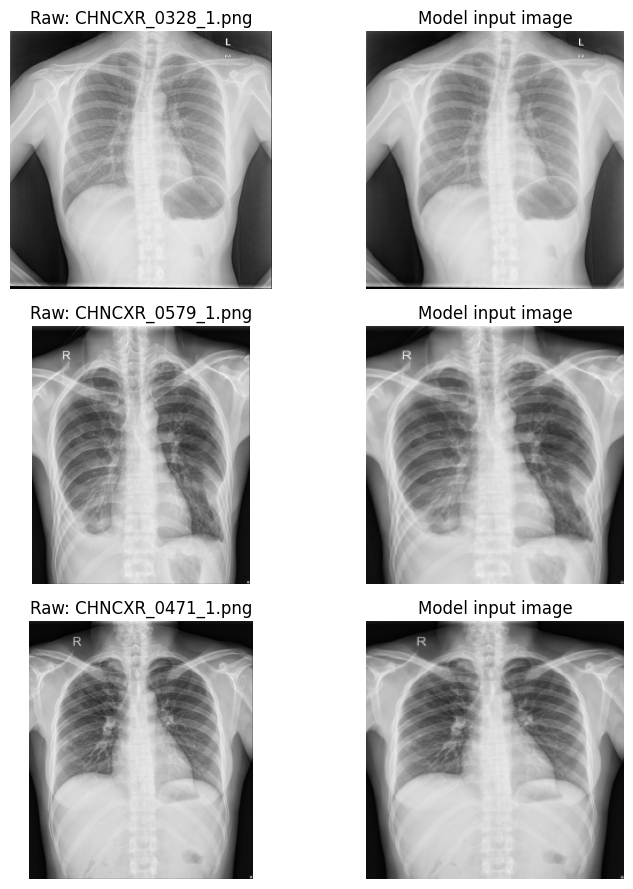

In [ ]:
# Bootstrap guard for out-of-order execution
required_names = [
    'SHENZHEN_META', 'MONT_META', 'SHENZHEN_IMAGE_DIR', 'MONT_IMAGE_DIR', 'BACKBONE_NAME'
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing configuration variables: " + ", ".join(missing) +
        ". Please run the 'Paths and configuration' cell first, then rerun this cell."
    )


df_shenzhen = filter_existing_images(load_metadata(SHENZHEN_META), SHENZHEN_IMAGE_DIR)
df_mont = filter_existing_images(load_metadata(MONT_META), MONT_IMAGE_DIR)

print("Shenzhen:", df_shenzhen.shape, df_shenzhen["label"].value_counts().to_dict())
print("Montgomery:", df_mont.shape, df_mont["label"].value_counts().to_dict())

show_preprocessing_examples(df_shenzhen, SHENZHEN_IMAGE_DIR, backbone_name=BACKBONE_NAME, n=3)


Shenzhen: (662, 6) {1: 336, 0: 326}
Montgomery: (138, 6) {0: 81, 1: 57}


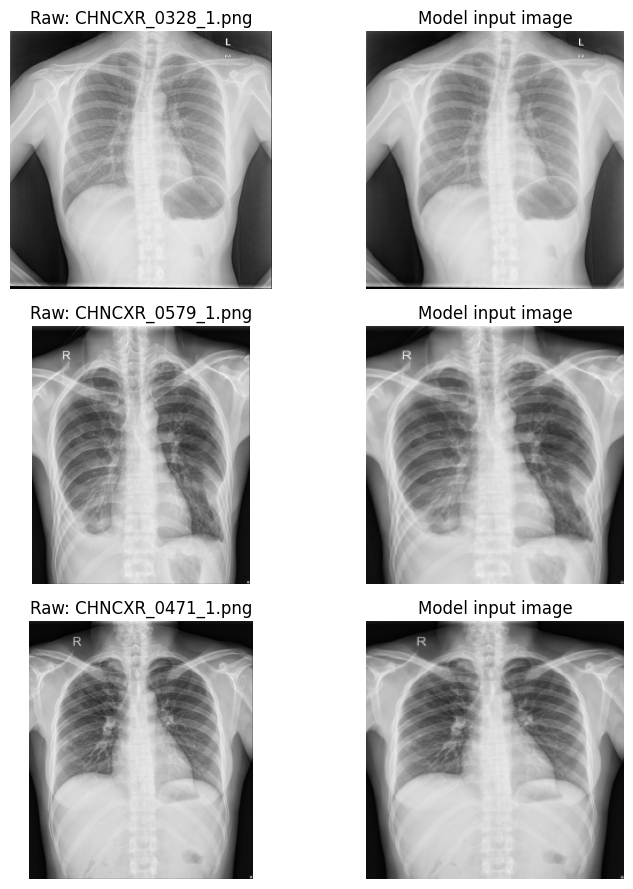

In [ ]:

# Bootstrap guard for out-of-order execution
required_names = [
    'SHENZHEN_META', 'MONT_META', 'SHENZHEN_IMAGE_DIR', 'MONT_IMAGE_DIR', 'BACKBONE_NAME'
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing configuration variables: " + ", ".join(missing) +
        ". Please run the 'Paths and configuration' cell first, then rerun this cell."
    )


df_shenzhen = filter_existing_images(load_metadata(SHENZHEN_META), SHENZHEN_IMAGE_DIR)
df_mont = filter_existing_images(load_metadata(MONT_META), MONT_IMAGE_DIR)

print("Shenzhen:", df_shenzhen.shape, df_shenzhen["label"].value_counts().to_dict())
print("Montgomery:", df_mont.shape, df_mont["label"].value_counts().to_dict())

show_preprocessing_examples(df_shenzhen, SHENZHEN_IMAGE_DIR, backbone_name=BACKBONE_NAME, n=3)


## 4) Model, optimizer, and loss

In [ ]:

class TBClassifier(nn.Module):
    def __init__(self, backbone_name: str, dropout: float = 0.30, freeze_backbone: bool = False):
        super().__init__()
        self.backbone_name = backbone_name
        self.encoder = timm.create_model(
            backbone_name,
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )
        feature_dim = self.encoder.num_features
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(feature_dim, 1)

        if freeze_backbone:
            for p in self.encoder.parameters():
                p.requires_grad = False

    def forward(self, x):
        feats = self.encoder(x)
        feats = self.dropout(feats)
        logits = self.head(feats).squeeze(1)
        return logits


def freeze_batchnorm(module):
    if isinstance(module, nn.BatchNorm2d):
        module.eval()
        for p in module.parameters():
            p.requires_grad = False


def set_fine_tuning(model: TBClassifier, freeze_backbone: bool, unfreeze_last_n_blocks: int = 2):
    if freeze_backbone:
        for p in model.encoder.parameters():
            p.requires_grad = False
        return

    # Default: unfreeze everything
    for p in model.encoder.parameters():
        p.requires_grad = True

    # Optionally freeze early blocks and only unfreeze last few named blocks when possible
    named_children = list(model.encoder.named_children())
    if len(named_children) > unfreeze_last_n_blocks:
        for _, child in named_children[:-unfreeze_last_n_blocks]:
            for p in child.parameters():
                p.requires_grad = False


def get_loss(loss_name: str, pos_weight=None):
    loss_name = loss_name.lower()
    if loss_name == "bce":
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    elif loss_name == "focal":
        class BinaryFocalLoss(nn.Module):
            def __init__(self, gamma=2.0, alpha=0.25):
                super().__init__()
                self.gamma = gamma
                self.alpha = alpha

            def forward(self, logits, targets):
                bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
                probs = torch.sigmoid(logits)
                pt = torch.where(targets == 1, probs, 1 - probs)
                focal = self.alpha * (1 - pt).pow(self.gamma) * bce
                return focal.mean()
        return BinaryFocalLoss()
    else:
        raise ValueError(f"Unsupported loss: {loss_name}")


def build_optimizer(model, optimizer_name: str, lr: float, weight_decay: float):
    optimizer_name = optimizer_name.lower()
    params = [p for p in model.parameters() if p.requires_grad]
    if optimizer_name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "adamw":
        return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    elif optimizer_name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr, alpha=0.99, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")


def make_loader(df, image_dir, backbone_name, batch_size, is_training):
    ds = TBCXRDataset(
        df, image_dir=image_dir, backbone_name=backbone_name, img_size=IMG_SIZE,
        use_clahe=USE_CLAHE, use_lung_crop=USE_LUNG_CROP, is_training=is_training
    )
    return DataLoader(
        ds, batch_size=batch_size, shuffle=is_training,
        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
    )


## 5) Training, evaluation, and calibration utilities

In [ ]:
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))


def run_epoch(model, loader, optimizer, criterion):
    train_mode = optimizer is not None
    if train_mode:
        model.train()
        if globals().get("FREEZE_BATCHNORM_DURING_FT", False):
            model.apply(freeze_batchnorm)
    else:
        model.eval()

    total_loss = 0.0
    total_count = 0
    all_probs = []
    all_targets = []

    with torch.set_grad_enabled(train_mode):
        for batch in loader:
            if not isinstance(batch, (list, tuple)) or len(batch) < 2:
                raise ValueError("Unexpected batch format from DataLoader; expected at least (x, y).")

            xb = batch[0].to(DEVICE)
            yb = batch[1].to(DEVICE).float().view(-1)

            if train_mode:
                optimizer.zero_grad(set_to_none=True)

            logits = model(xb).view(-1)
            loss = criterion(logits, yb)

            if train_mode:
                loss.backward()
                optimizer.step()

            probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
            targets = yb.detach().cpu().numpy().ravel()

            batch_size = int(yb.shape[0])
            total_loss += float(loss.item()) * batch_size
            total_count += batch_size
            all_probs.append(probs)
            all_targets.append(targets)

    avg_loss = total_loss / max(total_count, 1)
    y_true = np.concatenate(all_targets) if all_targets else np.array([], dtype=np.float32)
    y_prob = np.concatenate(all_probs) if all_probs else np.array([], dtype=np.float32)

    if y_true.size == 0:
        metrics = {
            "loss": avg_loss,
            "roc_auc": np.nan,
            "pr_auc": np.nan,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "specificity": np.nan,
            "f1": np.nan,
            "brier": np.nan,
            "log_loss": np.nan,
        }
        return metrics, y_true, y_prob

    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "loss": avg_loss,
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "brier": brier_score_loss(y_true, y_prob),
        "log_loss": log_loss(y_true, np.clip(y_prob, 1e-6, 1 - 1e-6)),
    }
    return metrics, y_true, y_prob


def specificity_score(y_true, y_pred_binary):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary, labels=[0, 1]).ravel()
    return tn / (tn + fp + 1e-8)


def threshold_for_target_sensitivity(y_true, y_prob, target_sensitivity=0.90):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_thr = 0.50
    best_spec = -1.0
    found = False

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        sens = recall_score(y_true, y_pred, zero_division=0)
        spec = specificity_score(y_true, y_pred)
        if sens >= target_sensitivity:
            found = True
            if spec > best_spec:
                best_spec = spec
                best_thr = float(thr)

    if not found:
        best_recall = -1.0
        best_spec = -1.0
        for thr in thresholds:
            y_pred = (y_prob >= thr).astype(int)
            sens = recall_score(y_true, y_pred, zero_division=0)
            spec = specificity_score(y_true, y_pred)
            if sens > best_recall or (sens == best_recall and spec > best_spec):
                best_recall = sens
                best_spec = spec
                best_thr = float(thr)

    return best_thr


def evaluate_with_threshold(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "brier": brier_score_loss(y_true, y_prob),
        "log_loss": log_loss(y_true, np.clip(y_prob, 1e-6, 1 - 1e-6)),
        "threshold": float(threshold),
    }


def safe_logit(p):
    p = np.clip(np.asarray(p, dtype=np.float64), 1e-6, 1 - 1e-6)
    return logit(p)


def fit_probability_calibrator(y_true, y_prob, method="platt"):
    method = (method or "none").lower()
    if method == "none":
        return {"method": "none"}
    if method != "platt":
        raise ValueError(f"Unsupported calibration method: {method}")

    X = safe_logit(y_prob).reshape(-1, 1)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X, y_true)
    return {"method": "platt", "model": clf}


def apply_probability_calibrator(calibrator, y_prob):
    if calibrator["method"] == "none":
        return y_prob
    X = safe_logit(y_prob).reshape(-1, 1)
    return calibrator["model"].predict_proba(X)[:, 1]


In [ ]:

# def sigmoid_np(x):
#     return 1.0 / (1.0 + np.exp(-x))


# def run_epoch(model, loader, optimizer, criterion):
#   train_mode = optimizer is not None
#   model.train(train_mode)

#   if train_mode and globals().get("FREEZE_BATCHNORM_DURING_FT", False):
#     model.apply(freeze_batchnorm)

#     total_loss = 0.0
#     total_count = 0
#     all_probs = []
#     all_targets = []

#     for xb, yb in loader:
#         xb = xb.to(DEVICE)
#         yb = yb.to(DEVICE).float().view(-1, 1)

#         if train_mode:
#             optimizer.zero_grad()

#         logits = model(xb)
#         loss = criterion(logits, yb)

#         if train_mode:
#             loss.backward()
#             optimizer.step()

#         probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
#         targets = yb.detach().cpu().numpy().ravel()

#         batch_size = len(yb)
#         total_loss += loss.item() * batch_size
#         total_count += batch_size

#         all_probs.append(probs)
#         all_targets.append(targets)

#     avg_loss = total_loss / max(total_count, 1)
#     y_true = np.concatenate(all_targets) if all_targets else np.array([])
#     y_prob = np.concatenate(all_probs) if all_probs else np.array([])

#     return avg_loss, y_true, y_prob


# def specificity_score(y_true, y_pred_binary):
#     tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
#     return tn / (tn + fp + 1e-8)


# def threshold_for_target_sensitivity(y_true, y_prob, target_sensitivity=0.90):
#     thresholds = np.linspace(0.01, 0.99, 99)
#     best_thr = 0.50
#     best_spec = -1.0
#     found = False
#     for thr in thresholds:
#         y_pred = (y_prob >= thr).astype(int)
#         sens = recall_score(y_true, y_pred, zero_division=0)
#         spec = specificity_score(y_true, y_pred)
#         if sens >= target_sensitivity:
#             found = True
#             if spec > best_spec:
#                 best_spec = spec
#                 best_thr = float(thr)

#     if not found:
#         best_recall = -1.0
#         best_spec = -1.0
#         for thr in thresholds:
#             y_pred = (y_prob >= thr).astype(int)
#             sens = recall_score(y_true, y_pred, zero_division=0)
#             spec = specificity_score(y_true, y_pred)
#             if sens > best_recall or (sens == best_recall and spec > best_spec):
#                 best_recall = sens
#                 best_spec = spec
#                 best_thr = float(thr)
#     return best_thr


# def evaluate_with_threshold(y_true, y_prob, threshold=0.50):
#     y_pred = (y_prob >= threshold).astype(int)
#     return {
#         "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
#         "pr_auc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
#         "accuracy": accuracy_score(y_true, y_pred),
#         "precision": precision_score(y_true, y_pred, zero_division=0),
#         "recall": recall_score(y_true, y_pred, zero_division=0),
#         "specificity": specificity_score(y_true, y_pred),
#         "f1": f1_score(y_true, y_pred, zero_division=0),
#         "brier": brier_score_loss(y_true, y_prob),
#         "log_loss": log_loss(y_true, np.clip(y_prob, 1e-6, 1 - 1e-6)),
#         "threshold": float(threshold),
#     }


# def safe_logit(p):
#     p = np.clip(np.asarray(p, dtype=np.float64), 1e-6, 1 - 1e-6)
#     return logit(p)


# def fit_probability_calibrator(y_true, y_prob, method="platt"):
#     method = (method or "none").lower()
#     if method == "none":
#         return {"method": "none"}
#     if method != "platt":
#         raise ValueError(f"Unsupported calibration method: {method}")
#     X = safe_logit(y_prob).reshape(-1, 1)
#     clf = LogisticRegression(max_iter=1000)
#     clf.fit(X, y_true)
#     return {"method": "platt", "model": clf}


# def apply_probability_calibrator(calibrator, y_prob):
#     if calibrator["method"] == "none":
#         return y_prob
#     X = safe_logit(y_prob).reshape(-1, 1)
#     return calibrator["model"].predict_proba(X)[:, 1]


## 6) Train once

In [ ]:
def train_model_once(
    df_train, df_val,
    backbone_name: str,
    optimizer_name: str,
    loss_name: str = "bce",
    freeze_backbone: bool = FREEZE_BACKBONE,
    lr_head: float = LR_HEAD,
    lr_ft: float = LR_FT,
    weight_decay: float = WEIGHT_DECAY,
    dropout: float = DROPOUT,
):
    train_loader = make_loader(df_train, SHENZHEN_IMAGE_DIR, backbone_name, BATCH_SIZE, is_training=True)
    val_loader = make_loader(df_val, SHENZHEN_IMAGE_DIR, backbone_name, BATCH_SIZE, is_training=False)

    model = TBClassifier(backbone_name, dropout=dropout, freeze_backbone=freeze_backbone).to(DEVICE)

    pos = max(float(df_train["label"].sum()), 1.0)
    neg = max(float(len(df_train) - df_train["label"].sum()), 1.0)
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=DEVICE)
    criterion = get_loss(loss_name, pos_weight=pos_weight)

    best_state = deepcopy(model.state_dict())
    best_val_auc = -np.inf
    patience_counter = 0
    history = []

    optimizer = build_optimizer(model, optimizer_name, lr=lr_head, weight_decay=weight_decay)

    for epoch in range(1, HEAD_EPOCHS + 1):
        tr_metrics, _, _ = run_epoch(model, train_loader, optimizer=optimizer, criterion=criterion)
        va_metrics, _, _ = run_epoch(model, val_loader, optimizer=None, criterion=criterion)
        row = {"stage": "head", "epoch": epoch, **tr_metrics, **{f"val_{k}": v for k, v in va_metrics.items()}}
        history.append(row)

        cur_auc = va_metrics["roc_auc"] if np.isfinite(va_metrics["roc_auc"]) else -np.inf
        if cur_auc > best_val_auc:
            best_val_auc = cur_auc
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"[Head] Epoch {epoch:02d} | train_auc={tr_metrics['roc_auc']:.4f} | val_auc={va_metrics['roc_auc']:.4f}")
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            break

    if not freeze_backbone and FT_EPOCHS > 0:
        set_fine_tuning(model, freeze_backbone=False, unfreeze_last_n_blocks=UNFREEZE_LAST_N_BLOCKS)
        optimizer = build_optimizer(model, optimizer_name, lr=lr_ft, weight_decay=weight_decay)
        patience_counter = 0

        for epoch in range(1, FT_EPOCHS + 1):
            tr_metrics, _, _ = run_epoch(model, train_loader, optimizer=optimizer, criterion=criterion)
            va_metrics, _, _ = run_epoch(model, val_loader, optimizer=None, criterion=criterion)
            row = {"stage": "ft", "epoch": epoch, **tr_metrics, **{f"val_{k}": v for k, v in va_metrics.items()}}
            history.append(row)

            cur_auc = va_metrics["roc_auc"] if np.isfinite(va_metrics["roc_auc"]) else -np.inf
            if cur_auc > best_val_auc:
                best_val_auc = cur_auc
                best_state = deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            print(f"[FT]   Epoch {epoch:02d} | train_auc={tr_metrics['roc_auc']:.4f} | val_auc={va_metrics['roc_auc']:.4f}")
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                break

    model.load_state_dict(best_state)
    val_metrics, y_val, y_val_prob = run_epoch(model, val_loader, optimizer=None, criterion=criterion)
    history_df = pd.DataFrame(history)
    return model, history_df, y_val, y_val_prob, val_metrics


## 7) Cross-validation benchmark across optimizers

In [ ]:

def run_cv_benchmark(
    df_shenzhen: pd.DataFrame,
    backbone_name: str,
    optimizer_name: str,
    loss_name: str = "bce",
    n_folds: int = 5,
    target_sensitivity: float = 0.90,
):
    print(f"\n=== CV Benchmark | backbone={backbone_name} | optimizer={optimizer_name} | loss={loss_name} ===")
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    fold_rows = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(df_shenzhen, df_shenzhen["label"]), start=1):
        print(f"\n--- Fold {fold}/{n_folds} ---")
        df_train = df_shenzhen.iloc[tr_idx].reset_index(drop=True)
        df_val = df_shenzhen.iloc[va_idx].reset_index(drop=True)

        model, history_df, y_val, val_prob, _ = train_model_once(
            df_train=df_train,
            df_val=df_val,
            backbone_name=backbone_name,
            optimizer_name=optimizer_name,
            loss_name=loss_name,
        )

        thr = threshold_for_target_sensitivity(y_val, val_prob, target_sensitivity=target_sensitivity)
        metrics = evaluate_with_threshold(y_val, val_prob, threshold=thr)
        metrics.update({
            "fold": fold,
            "backbone": backbone_name,
            "optimizer": optimizer_name,
            "loss": loss_name
        })
        fold_rows.append(metrics)

    return pd.DataFrame(fold_rows)


Debug batch-inspection cell removed in v4 to avoid `loader` NameError during Run All.

In [ ]:

all_cv_results = []

for backbone_name in BACKBONES:
    for optimizer_name in OPTIMIZERS:
        cv_df = run_cv_benchmark(
            df_shenzhen=df_shenzhen,
            backbone_name=backbone_name,
            optimizer_name=optimizer_name,
            loss_name=LOSS_NAME,
            n_folds=N_FOLDS,
            target_sensitivity=TARGET_SENSITIVITY,
        )
        all_cv_results.append(cv_df)

cv_results = pd.concat(all_cv_results, ignore_index=True)
cv_results



=== CV Benchmark | backbone=resnet18 | optimizer=adam | loss=bce ===

--- Fold 1/5 ---
[Head] Epoch 01 | train_auc=0.6883 | val_auc=0.8245
[Head] Epoch 02 | train_auc=0.7358 | val_auc=0.8033
[Head] Epoch 03 | train_auc=0.7097 | val_auc=0.8670
[Head] Epoch 04 | train_auc=0.7707 | val_auc=0.8982
[Head] Epoch 05 | train_auc=0.7662 | val_auc=0.9048
[FT]   Epoch 01 | train_auc=0.8137 | val_auc=0.9046
[FT]   Epoch 02 | train_auc=0.7896 | val_auc=0.9025
[FT]   Epoch 03 | train_auc=0.7807 | val_auc=0.9086
[FT]   Epoch 04 | train_auc=0.7709 | val_auc=0.9066
[FT]   Epoch 05 | train_auc=0.8145 | val_auc=0.9062
[FT]   Epoch 06 | train_auc=0.7811 | val_auc=0.9107
[FT]   Epoch 07 | train_auc=0.7782 | val_auc=0.9086
[FT]   Epoch 08 | train_auc=0.8181 | val_auc=0.9073
[FT]   Epoch 09 | train_auc=0.8107 | val_auc=0.9057
[FT]   Epoch 10 | train_auc=0.7939 | val_auc=0.9064

--- Fold 2/5 ---
[Head] Epoch 01 | train_auc=0.6515 | val_auc=0.8665
[Head] Epoch 02 | train_auc=0.7246 | val_auc=0.8681
[Head] Epo

,roc_auc,pr_auc,accuracy,precision,recall,specificity,f1,brier,log_loss,threshold,fold,backbone,optimizer,loss
0,0.910674,0.907245,0.857143,0.815789,0.925373,0.787879,0.867133,0.133039,0.413765,0.29,1,resnet18,adam,bce
1,0.910181,0.922452,0.827068,0.784810,0.911765,0.738462,0.843537,0.187627,0.551161,0.27,2,resnet18,adam,bce
2,0.891619,0.921183,0.734848,0.673913,0.925373,0.538462,0.779874,0.133083,0.417030,0.29,3,resnet18,adam,bce
3,0.882434,0.900473,0.712121,0.652632,0.925373,0.492308,0.765432,0.317082,1.083018,0.85,4,resnet18,adam,bce
4,0.861079,0.895110,0.712121,0.655914,0.910448,0.507692,0.762500,0.156521,0.489565,0.16,5,resnet18,adam,bce
5,0.914066,0.924166,0.827068,0.782051,0.910448,0.742424,0.841379,0.124668,0.403879,0.35,1,resnet18,adamw,bce
6,0.920136,0.935452,0.781955,0.729412,0.911765,0.646154,0.810458,0.190257,0.564449,0.10,2,resnet18,adamw,bce
7,0.890241,0.914069,0.704545,0.648936,0.910448,0.492308,0.757764,0.149892,0.455746,0.16,3,resnet18,adamw,bce
8,0.892078,0.914070,0.848485,0.813333,0.910448,0.784615,0.859155,0.124084,0.412828,0.31,4,resnet18,adamw,bce
9,0.863605,0.897821,0.606061,0.570093,0.910448,0.292308,0.701149,0.153766,0.484506,0.12,5,resnet18,adamw,bce


In [ ]:

summary_cols = ["roc_auc", "pr_auc", "recall", "specificity", "f1", "threshold"]
cv_summary = (
    cv_results.groupby(["backbone", "optimizer", "loss"])[summary_cols]
    .agg(["mean", "std"])
    .round(4)
)
cv_summary


roc_auc          pr_auc          recall          \
                           mean     std    mean     std    mean     std   
backbone optimizer loss                                                   
resnet18 adam      bce   0.8912  0.0208  0.9093  0.0122  0.9197  0.0078   
         adamw     bce   0.8960  0.0224  0.9171  0.0139  0.9107  0.0006   
         rmsprop   bce   0.7472  0.0587  0.7513  0.0641  0.9701  0.0422   
         sgd       bce   0.8052  0.0504  0.8058  0.0498  0.9255  0.0151   

                        specificity              f1         threshold          
                               mean     std    mean     std      mean     std  
backbone optimizer loss                                                        
resnet18 adam      bce       0.6130  0.1392  0.8037  0.0483     0.372  0.2726  
         adamw     bce       0.5916  0.2015  0.7940  0.0646     0.208  0.1143  
         rmsprop   bce       0.1042  0.1274  0.6840  0.0236     0.300  0.2657  
         sgd       bce       0.4138  0.1333  0.7437  0.0401     0.452  0.0130

In [ ]:

ranking = (
    cv_results.groupby(["backbone", "optimizer", "loss"])[["recall", "pr_auc", "roc_auc", "specificity"]]
    .mean()
    .sort_values(["recall", "pr_auc", "roc_auc", "specificity"], ascending=False)
    .reset_index()
)
ranking


,backbone,optimizer,loss,recall,pr_auc,roc_auc,specificity
0,resnet18,rmsprop,bce,0.970149,0.751261,0.747154,0.104196
1,resnet18,sgd,bce,0.925549,0.805812,0.805181,0.413846
2,resnet18,adam,bce,0.919666,0.909293,0.891197,0.612960
3,resnet18,adamw,bce,0.910711,0.917116,0.896025,0.591562


In [ ]:

best_backbone = ranking.iloc[0]["backbone"]
best_optimizer = ranking.iloc[0]["optimizer"]
best_loss = ranking.iloc[0]["loss"]

best_threshold = (
    cv_results[
        (cv_results["backbone"] == best_backbone) &
        (cv_results["optimizer"] == best_optimizer) &
        (cv_results["loss"] == best_loss)
    ]["threshold"].mean()
)

print("Selected best backbone:", best_backbone)
print("Selected best optimizer:", best_optimizer)
print("Selected best loss:", best_loss)
print("Average Shenzhen threshold:", round(float(best_threshold), 4))


Selected best backbone: resnet18
Selected best optimizer: rmsprop
Selected best loss: bce
Average Shenzhen threshold: 0.3


## 8) Final training and locked external test

In [ ]:

df_train_final, df_dev_final = train_test_split(
    df_shenzhen,
    test_size=FINAL_DEV_RATIO,
    random_state=SEED,
    stratify=df_shenzhen["label"],
)

df_calib_final, df_thr_final = train_test_split(
    df_dev_final,
    test_size=CALIBRATION_SPLIT_RATIO,
    random_state=SEED,
    stratify=df_dev_final["label"],
)

final_model, final_history, y_calib_raw, calib_prob_raw, _ = train_model_once(
    df_train=df_train_final,
    df_val=df_calib_final,
    backbone_name=best_backbone,
    optimizer_name=best_optimizer,
    loss_name=best_loss,
)

thr_prob_raw_loader = make_loader(df_thr_final, SHENZHEN_IMAGE_DIR, best_backbone, BATCH_SIZE, is_training=False)
criterion_tmp = get_loss(best_loss, pos_weight=None)
_, y_thr_final, thr_prob_raw = run_epoch(final_model, thr_prob_raw_loader, optimizer=None, criterion=criterion_tmp)

calibrator = fit_probability_calibrator(y_calib_raw, calib_prob_raw, method=CALIBRATION_METHOD)
thr_prob = apply_probability_calibrator(calibrator, thr_prob_raw)
final_threshold = threshold_for_target_sensitivity(y_thr_final, thr_prob, target_sensitivity=TARGET_SENSITIVITY)

print("Final locked threshold:", round(float(final_threshold), 4))


In [ ]:

mont_loader = make_loader(df_mont, MONT_IMAGE_DIR, best_backbone, BATCH_SIZE, is_training=False)
criterion_tmp = get_loss(best_loss, pos_weight=None)
_, y_mont, mont_prob_raw = run_epoch(final_model, mont_loader, optimizer=None, criterion=criterion_tmp)

mont_prob = apply_probability_calibrator(calibrator, mont_prob_raw)
mont_metrics = evaluate_with_threshold(y_mont, mont_prob, threshold=final_threshold)

print("Locked Montgomery evaluation")
pd.Series(mont_metrics)


In [ ]:

diag_rows = []
for thr in np.linspace(0.01, 0.99, 99):
    row = evaluate_with_threshold(y_mont, mont_prob, threshold=float(thr))
    row["threshold"] = float(thr)
    diag_rows.append(row)

diag_df = pd.DataFrame(diag_rows)

plt.figure(figsize=(8, 5))
plt.plot(diag_df["threshold"], diag_df["recall"], label="Recall / Sensitivity")
plt.plot(diag_df["threshold"], diag_df["specificity"], label="Specificity")
plt.plot(diag_df["threshold"], diag_df["precision"], label="Precision")
plt.axvline(final_threshold, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Montgomery calibrated threshold diagnostics")
plt.legend()
plt.show()


## 9) Explainability with Grad-CAM: internal and external test sets

This section applies **Gradient-weighted Class Activation Mapping (Grad-CAM)** to interpret the final ResNet18 model decisions.

Grad-CAM highlights the image regions that most strongly contributed to the model score for the positive class, **tuberculosis**. The visualisations below are generated for both:

- the internal locked Shenzhen threshold/test split (`df_thr_final`)
- the external Montgomery test set (`df_mont`)

For scientific reporting, inspect representative **TP, TN, FP, and FN** cases rather than only the best-looking examples.


In [ ]:
# =========================
# Grad-CAM utilities: robust to frozen encoders / timm wrappers
# =========================
import matplotlib.cm as cm
from collections import defaultdict


def get_last_conv_layer(model: nn.Module):
    base_model = model.module if hasattr(model, "module") else model
    search_root = base_model.encoder if hasattr(base_model, "encoder") else base_model

    last_name, last_module = None, None
    for name, module in search_root.named_modules():
        if isinstance(module, nn.Conv2d):
            last_name, last_module = name, module

    if last_module is None:
        raise RuntimeError("No Conv2d layer found for Grad-CAM.")

    prefix = "encoder." if hasattr(base_model, "encoder") else ""
    print(f"Using Grad-CAM target layer: {prefix}{last_name}")
    return last_module


class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self._hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inputs, output):
            self.activations = output
            if not self.activations.requires_grad:
                self.activations.requires_grad_(True)
            self.activations.retain_grad()

        self._hooks.append(self.target_layer.register_forward_hook(forward_hook))

    def remove_hooks(self):
        for hook in self._hooks:
            hook.remove()
        self._hooks = []

    def __call__(self, x: torch.Tensor):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        self.activations = None

        with torch.enable_grad():
            x = x.to(DEVICE).detach()
            x.requires_grad_(True)

            logits = self.model(x).view(-1)
            score = logits.sum()
            score.backward(retain_graph=False)

        if self.activations is None:
            raise RuntimeError(
                "Grad-CAM forward hook did not fire. "
                "The selected target layer is probably not used in the forward pass."
            )

        gradients = self.activations.grad
        if gradients is None:
            raise RuntimeError(
                "Grad-CAM did not obtain gradients for the target activations. "
                "Re-run this corrected utility cell."
            )

        activations = self.activations.detach()
        gradients = gradients.detach()

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1)
        cam = torch.relu(cam)

        cam = torch.nn.functional.interpolate(
            cam.unsqueeze(1),
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False,
        ).squeeze(1)

        cam_min = cam.flatten(1).min(dim=1)[0].view(-1, 1, 1)
        cam_max = cam.flatten(1).max(dim=1)[0].view(-1, 1, 1)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        probs = torch.sigmoid(logits.detach()).cpu().numpy()
        return cam.detach().cpu().numpy(), probs


def collect_predictions_with_ids(model, df, image_dir, backbone_name, calibrator=None, threshold=0.50):
    loader = make_loader(df, image_dir, backbone_name, BATCH_SIZE, is_training=False)
    model.eval()

    rows = []
    with torch.no_grad():
        for xb, yb, study_ids in loader:
            xb = xb.to(DEVICE)
            logits = model(xb).view(-1)
            raw_probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
            y_true = yb.detach().cpu().numpy().astype(int).ravel()

            probs = apply_probability_calibrator(calibrator, raw_probs) if calibrator is not None else raw_probs

            for sid, yt, raw_p, p in zip(study_ids, y_true, raw_probs, probs):
                rows.append({
                    "study_id": str(sid),
                    "y_true": int(yt),
                    "raw_prob": float(raw_p),
                    "prob": float(p),
                    "y_pred": int(p >= threshold),
                })

    out = pd.DataFrame(rows)
    out["case_type"] = np.select(
        [
            (out["y_true"] == 1) & (out["y_pred"] == 1),
            (out["y_true"] == 0) & (out["y_pred"] == 0),
            (out["y_true"] == 0) & (out["y_pred"] == 1),
            (out["y_true"] == 1) & (out["y_pred"] == 0),
        ],
        ["TP", "TN", "FP", "FN"],
        default="NA",
    )
    return out


def _read_display_image(study_id, image_dir, img_size=IMG_SIZE):
    img_path = resolve_image_file(image_dir, str(study_id))
    if img_path is None:
        raise FileNotFoundError(f"Image not found for study_id={study_id}")

    ds_tmp = TBCXRDataset(
        pd.DataFrame([{"study_id": study_id, "label": 0}]),
        image_dir=image_dir,
        backbone_name=best_backbone,
        img_size=img_size,
        use_clahe=USE_CLAHE,
        use_lung_crop=USE_LUNG_CROP,
        is_training=False,
    )
    return ds_tmp._read_image(img_path)


def _tensor_for_study(study_id, true_label, image_dir, backbone_name=best_backbone):
    row_df = pd.DataFrame([{"study_id": study_id, "label": int(true_label)}])
    ds = TBCXRDataset(
        row_df,
        image_dir=image_dir,
        backbone_name=backbone_name,
        img_size=IMG_SIZE,
        use_clahe=USE_CLAHE,
        use_lung_crop=USE_LUNG_CROP,
        is_training=False,
    )
    x, y, sid = ds[0]
    return x.unsqueeze(0), int(y.item()), str(sid)


def make_gradcam_overlay(rgb_img, heatmap, alpha=0.45):
    heatmap_uint8 = np.uint8(255 * np.clip(heatmap, 0, 1))
    heatmap_color = cm.get_cmap("jet")(heatmap_uint8)[:, :, :3]
    heatmap_color = np.uint8(255 * heatmap_color)
    overlay = np.uint8((1 - alpha) * rgb_img + alpha * heatmap_color)
    return overlay


def choose_representative_cases(pred_df, max_per_type=2):
    selected = []

    for case_type in ["TP", "TN", "FP", "FN"]:
        subset = pred_df[pred_df["case_type"] == case_type].copy()
        if subset.empty:
            continue

        if case_type in ["TP", "FP"]:
            subset = subset.sort_values("prob", ascending=False)
        else:
            subset = subset.sort_values("prob", ascending=True)

        selected.append(subset.head(max_per_type))

    if not selected:
        return pred_df.head(0).copy()

    return pd.concat(selected, ignore_index=True)


def plot_gradcam_cases(model, pred_df, image_dir, title, max_per_type=2):
    selected = choose_representative_cases(pred_df, max_per_type=max_per_type)

    if selected.empty:
        print(f"No cases available for {title}.")
        return selected

    target_layer = get_last_conv_layer(model)
    gradcam = GradCAM(model, target_layer)

    n = len(selected)
    fig, axes = plt.subplots(n, 2, figsize=(9, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    try:
        for i, row in selected.iterrows():
            sid = row["study_id"]
            true_label = int(row["y_true"])

            x, _, _ = _tensor_for_study(
                sid,
                true_label,
                image_dir,
                backbone_name=best_backbone,
            )

            heatmaps, _ = gradcam(x)
            heatmap = heatmaps[0]

            rgb_img = _read_display_image(sid, image_dir, img_size=IMG_SIZE)
            overlay = make_gradcam_overlay(rgb_img, heatmap)

            label_name = "TB" if true_label == 1 else "Normal"
            pred_name = "TB" if int(row["y_pred"]) == 1 else "Normal"

            axes[i, 0].imshow(rgb_img)
            axes[i, 0].set_title(
                f"{title}\n{row['case_type']} | ID={sid}\nTrue={label_name}"
            )
            axes[i, 0].axis("off")

            axes[i, 1].imshow(overlay)
            axes[i, 1].set_title(
                f"Grad-CAM for TB score\nPred={pred_name} | p(TB)={row['prob']:.3f}"
            )
            axes[i, 1].axis("off")

    finally:
        gradcam.remove_hooks()

    plt.tight_layout()
    plt.show()

    return selected

In [ ]:
# =========================
# Internal locked Shenzhen test split
# =========================
internal_pred_df = collect_predictions_with_ids(
    final_model,
    df_thr_final,
    SHENZHEN_IMAGE_DIR,
    best_backbone,
    calibrator=calibrator,
    threshold=final_threshold,
)

print("Internal locked test split confusion categories:")
display(internal_pred_df["case_type"].value_counts().rename("count").to_frame())

internal_gradcam_cases = plot_gradcam_cases(
    final_model,
    internal_pred_df,
    SHENZHEN_IMAGE_DIR,
    title="Internal Shenzhen locked test split",
    max_per_type=2,
)

display(internal_gradcam_cases)

In [ ]:
# =========================
# External Montgomery test set
# =========================
external_pred_df = collect_predictions_with_ids(
    final_model,
    df_mont,
    MONT_IMAGE_DIR,
    best_backbone,
    calibrator=calibrator,
    threshold=final_threshold,
)

print("External Montgomery test set confusion categories:")
display(external_pred_df["case_type"].value_counts().rename("count").to_frame())

external_gradcam_cases = plot_gradcam_cases(
    final_model,
    external_pred_df,
    MONT_IMAGE_DIR,
    title="External Montgomery test set",
    max_per_type=2,
)

display(external_gradcam_cases)

In [ ]:

# # =========================
# # Grad-CAM utilities
# # =========================
# import matplotlib.cm as cm
# from collections import defaultdict


# def get_last_conv_layer(model: nn.Module):
#     """
#     Return the last Conv2d module in the encoder.

#     For timm ResNet18 this is typically in encoder.layer4, but this generic
#     fallback keeps the function robust if the backbone is changed later.
#     """
#     last_name = None
#     last_module = None
#     for name, module in model.encoder.named_modules():
#         if isinstance(module, nn.Conv2d):
#             last_name = name
#             last_module = module
#     if last_module is None:
#         raise RuntimeError("No Conv2d layer found in model.encoder for Grad-CAM.")
#     print(f"Using Grad-CAM target layer: encoder.{last_name}")
#     return last_module


# class GradCAM:
#     """
#     Minimal Grad-CAM implementation for a binary PyTorch classifier.

#     The model output is a single logit. We backpropagate the positive-class
#     logit, so the heatmap answers: 'Which regions increased the TB score?'
#     """
#     def __init__(self, model: nn.Module, target_layer: nn.Module):
#         self.model = model
#         self.target_layer = target_layer
#         self.activations = None
#         self.gradients = None
#         self._hooks = []
#         self._register_hooks()

#     def _register_hooks(self):
#         def forward_hook(module, inputs, output):
#             self.activations = output.detach()

#         def backward_hook(module, grad_input, grad_output):
#             self.gradients = grad_output[0].detach()

#         self._hooks.append(self.target_layer.register_forward_hook(forward_hook))
#         self._hooks.append(self.target_layer.register_full_backward_hook(backward_hook))

#     def remove_hooks(self):
#         for hook in self._hooks:
#             hook.remove()
#         self._hooks = []

#     def __call__(self, x: torch.Tensor):
#         self.model.eval()
#         self.model.zero_grad(set_to_none=True)

#         x = x.to(DEVICE)
#         logits = self.model(x).view(-1)
#         score = logits.sum()
#         score.backward()

#         if self.activations is None or self.gradients is None:
#             raise RuntimeError("Grad-CAM hooks did not capture activations/gradients.")

#         # Global-average-pool gradients over spatial dimensions to get channel weights.
#         weights = self.gradients.mean(dim=(2, 3), keepdim=True)
#         cam = (weights * self.activations).sum(dim=1)
#         cam = torch.relu(cam)

#         # Resize CAM to model input size.
#         cam = torch.nn.functional.interpolate(
#             cam.unsqueeze(1),
#             size=x.shape[-2:],
#             mode="bilinear",
#             align_corners=False,
#         ).squeeze(1)

#         # Normalize each heatmap to [0, 1].
#         cam_min = cam.flatten(1).min(dim=1)[0].view(-1, 1, 1)
#         cam_max = cam.flatten(1).max(dim=1)[0].view(-1, 1, 1)
#         cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

#         probs = torch.sigmoid(logits.detach()).cpu().numpy()
#         return cam.detach().cpu().numpy(), probs


# def collect_predictions_with_ids(model, df, image_dir, backbone_name, calibrator=None, threshold=0.50):
#     """
#     Run inference and return a dataframe with study IDs, true labels,
#     raw probabilities, calibrated probabilities, and predicted labels.
#     """
#     loader = make_loader(df, image_dir, backbone_name, BATCH_SIZE, is_training=False)
#     model.eval()

#     rows = []
#     with torch.no_grad():
#         for xb, yb, study_ids in loader:
#             xb = xb.to(DEVICE)
#             logits = model(xb).view(-1)
#             raw_probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
#             y_true = yb.detach().cpu().numpy().astype(int).ravel()

#             if calibrator is not None:
#                 probs = apply_probability_calibrator(calibrator, raw_probs)
#             else:
#                 probs = raw_probs

#             for sid, yt, raw_p, p in zip(study_ids, y_true, raw_probs, probs):
#                 rows.append({
#                     "study_id": str(sid),
#                     "y_true": int(yt),
#                     "raw_prob": float(raw_p),
#                     "prob": float(p),
#                     "y_pred": int(p >= threshold),
#                 })

#     out = pd.DataFrame(rows)
#     out["case_type"] = np.select(
#         [
#             (out["y_true"] == 1) & (out["y_pred"] == 1),
#             (out["y_true"] == 0) & (out["y_pred"] == 0),
#             (out["y_true"] == 0) & (out["y_pred"] == 1),
#             (out["y_true"] == 1) & (out["y_pred"] == 0),
#         ],
#         ["TP", "TN", "FP", "FN"],
#         default="NA"
#     )
#     return out


# def _read_display_image(study_id, image_dir, img_size=IMG_SIZE):
#     """
#     Read the same preprocessed image pathway used by the dataset, but return
#     an RGB uint8 image for plotting and overlay.
#     """
#     img_path = resolve_image_file(image_dir, str(study_id))
#     if img_path is None:
#         raise FileNotFoundError(f"Image not found for study_id={study_id}")

#     ds_tmp = TBCXRDataset(
#         pd.DataFrame([{"study_id": study_id, "label": 0}]),
#         image_dir=image_dir,
#         backbone_name=best_backbone,
#         img_size=img_size,
#         use_clahe=USE_CLAHE,
#         use_lung_crop=USE_LUNG_CROP,
#         is_training=False,
#     )
#     img = ds_tmp._read_image(img_path)
#     return img


# def _tensor_for_study(study_id, true_label, image_dir, backbone_name=best_backbone):
#     row_df = pd.DataFrame([{"study_id": study_id, "label": int(true_label)}])
#     ds = TBCXRDataset(
#         row_df,
#         image_dir=image_dir,
#         backbone_name=backbone_name,
#         img_size=IMG_SIZE,
#         use_clahe=USE_CLAHE,
#         use_lung_crop=USE_LUNG_CROP,
#         is_training=False,
#     )
#     x, y, sid = ds[0]
#     return x.unsqueeze(0), int(y.item()), str(sid)


# def make_gradcam_overlay(rgb_img, heatmap, alpha=0.45):
#     """
#     Overlay a Grad-CAM heatmap on an RGB image.
#     """
#     heatmap_uint8 = np.uint8(255 * np.clip(heatmap, 0, 1))
#     heatmap_color = cm.get_cmap("jet")(heatmap_uint8)[:, :, :3]
#     heatmap_color = np.uint8(255 * heatmap_color)
#     overlay = np.uint8((1 - alpha) * rgb_img + alpha * heatmap_color)
#     return overlay


# def choose_representative_cases(pred_df, max_per_type=2):
#     """
#     Select representative cases from each confusion-matrix category.

#     The sorting favors high-confidence examples within each category:
#     TP/FP by high predicted TB probability, TN/FN by low predicted TB probability.
#     """
#     selected = []
#     for case_type in ["TP", "TN", "FP", "FN"]:
#         subset = pred_df[pred_df["case_type"] == case_type].copy()
#         if subset.empty:
#             continue

#         if case_type in ["TP", "FP"]:
#             subset = subset.sort_values("prob", ascending=False)
#         else:
#             subset = subset.sort_values("prob", ascending=True)

#         selected.append(subset.head(max_per_type))

#     if not selected:
#         return pred_df.head(0).copy()
#     return pd.concat(selected, ignore_index=True)


# def plot_gradcam_cases(model, pred_df, image_dir, title, max_per_type=2):
#     """
#     Plot raw/preprocessed images and Grad-CAM overlays for representative cases.
#     """
#     selected = choose_representative_cases(pred_df, max_per_type=max_per_type)
#     if selected.empty:
#         print(f"No cases available for {title}.")
#         return selected

#     target_layer = get_last_conv_layer(model)
#     gradcam = GradCAM(model, target_layer)

#     n = len(selected)
#     fig, axes = plt.subplots(n, 2, figsize=(9, 4 * n))
#     if n == 1:
#         axes = np.expand_dims(axes, axis=0)

#     for i, row in selected.iterrows():
#         sid = row["study_id"]
#         true_label = int(row["y_true"])

#         x, _, _ = _tensor_for_study(sid, true_label, image_dir, backbone_name=best_backbone)
#         heatmaps, _ = gradcam(x)
#         heatmap = heatmaps[0]

#         rgb_img = _read_display_image(sid, image_dir, img_size=IMG_SIZE)
#         overlay = make_gradcam_overlay(rgb_img, heatmap)

#         label_name = "TB" if true_label == 1 else "Normal"
#         pred_name = "TB" if int(row["y_pred"]) == 1 else "Normal"

#         axes[i, 0].imshow(rgb_img)
#         axes[i, 0].set_title(f"{title}\n{row['case_type']} | ID={sid}\nTrue={label_name}")
#         axes[i, 0].axis("off")

#         axes[i, 1].imshow(overlay)
#         axes[i, 1].set_title(
#             f"Grad-CAM for TB score\nPred={pred_name} | p(TB)={row['prob']:.3f}"
#         )
#         axes[i, 1].axis("off")

#     plt.tight_layout()
#     plt.show()
#     gradcam.remove_hooks()
#     return selected


In [ ]:

# # =========================
# # Internal locked Shenzhen test split: predictions + Grad-CAM
# # =========================
# internal_pred_df = collect_predictions_with_ids(
#     final_model,
#     df_thr_final,
#     SHENZHEN_IMAGE_DIR,
#     best_backbone,
#     calibrator=calibrator,
#     threshold=final_threshold,
# )

# print("Internal locked test split confusion categories:")
# display(internal_pred_df["case_type"].value_counts().rename("count").to_frame())

# internal_gradcam_cases = plot_gradcam_cases(
#     final_model,
#     internal_pred_df,
#     SHENZHEN_IMAGE_DIR,
#     title="Internal Shenzhen locked test split",
#     max_per_type=2,
# )

# display(internal_gradcam_cases)


In [ ]:

# # =========================
# # External Montgomery test set: predictions + Grad-CAM
# # =========================
# external_pred_df = collect_predictions_with_ids(
#     final_model,
#     df_mont,
#     MONT_IMAGE_DIR,
#     best_backbone,
#     calibrator=calibrator,
#     threshold=final_threshold,
# )

# print("External Montgomery test set confusion categories:")
# display(external_pred_df["case_type"].value_counts().rename("count").to_frame())

# external_gradcam_cases = plot_gradcam_cases(
#     final_model,
#     external_pred_df,
#     MONT_IMAGE_DIR,
#     title="External Montgomery test set",
#     max_per_type=2,
# )

# display(external_gradcam_cases)


In [ ]:

# =========================
# Optional: save Grad-CAM case tables for reporting
# =========================
gradcam_internal_csv = "gradcam_internal_shenzhen_cases.csv"
gradcam_external_csv = "gradcam_external_montgomery_cases.csv"

internal_gradcam_cases.to_csv(gradcam_internal_csv, index=False)
external_gradcam_cases.to_csv(gradcam_external_csv, index=False)

print("Saved:")
print(" -", gradcam_internal_csv)
print(" -", gradcam_external_csv)
